In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv


In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv(r"/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv")

In [4]:
df.head(5)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [6]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

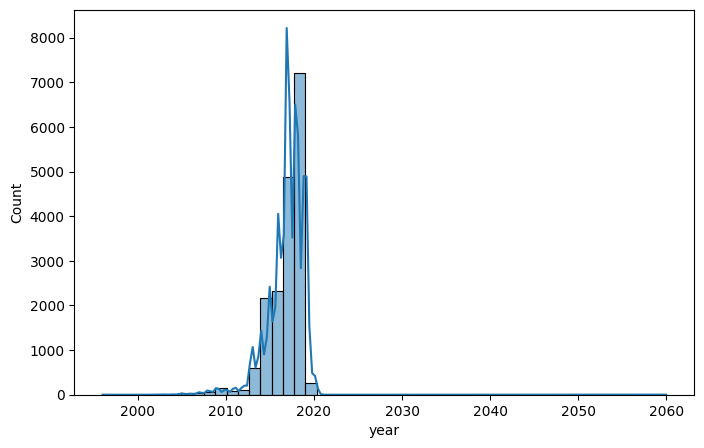

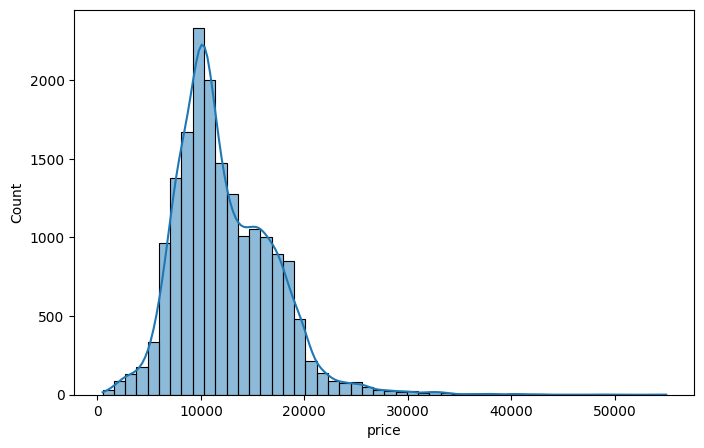

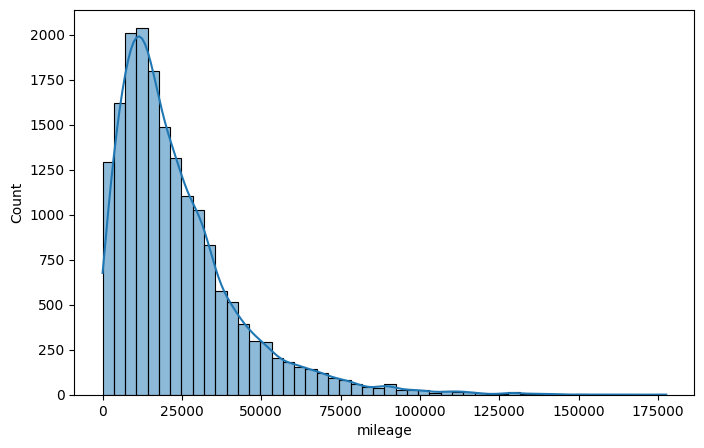

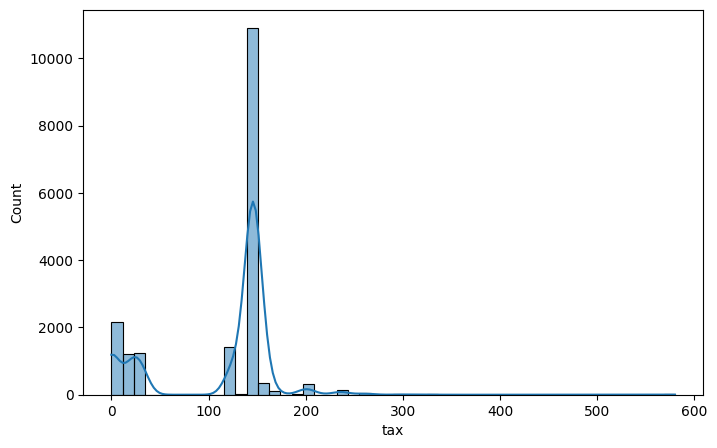

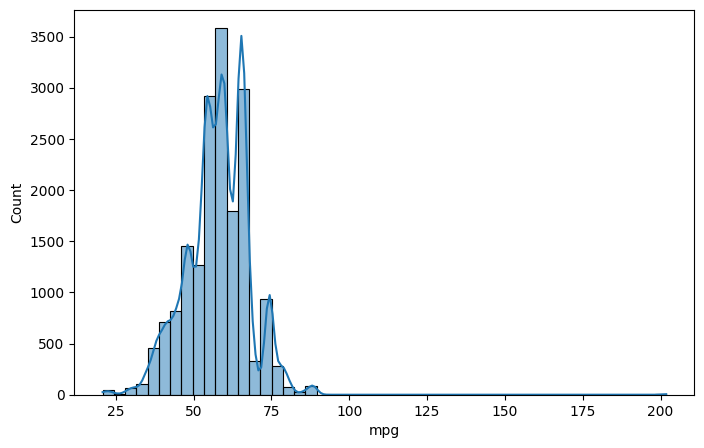

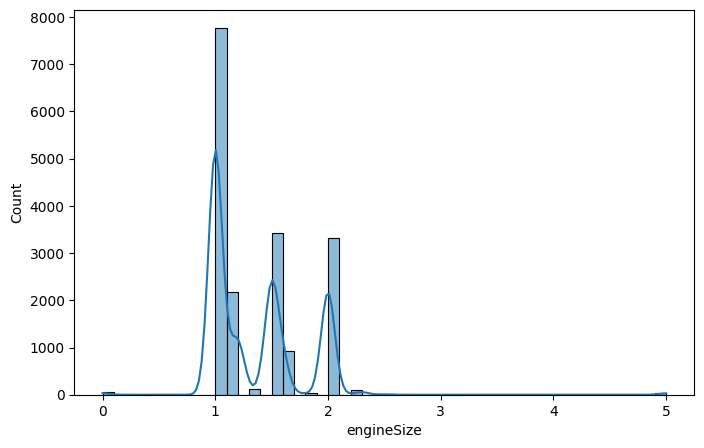

In [7]:
for num in df.select_dtypes(include='number'):
    plt.figure(figsize=(8,5))
    sns.histplot(df[num] , kde = True , bins = 50)

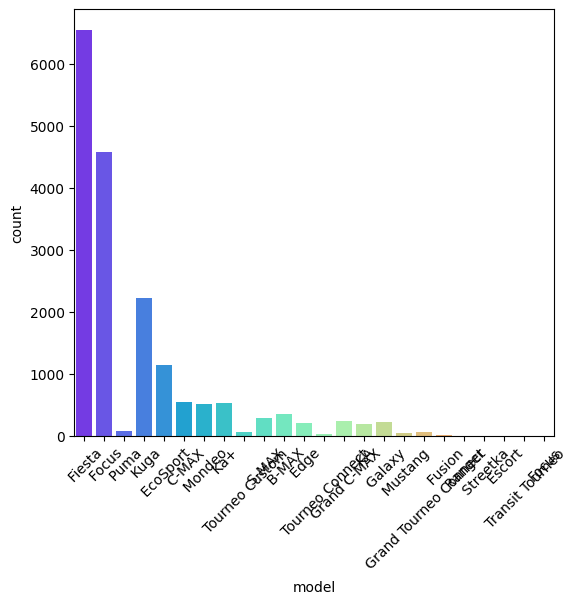

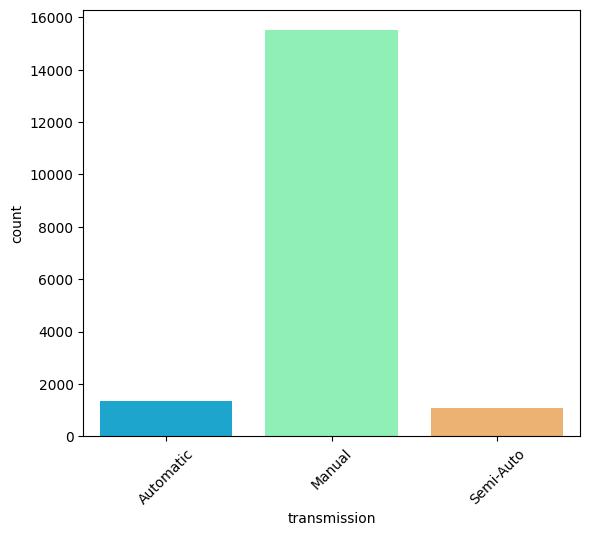

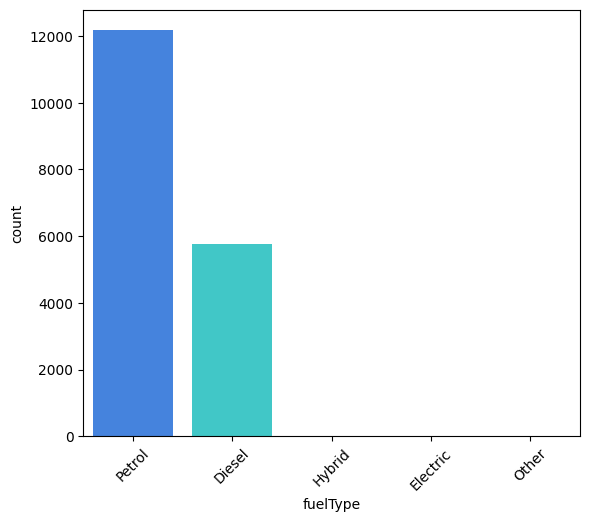

In [8]:
for obj in df.select_dtypes(include='object'):
    plt.figure(figsize=(6, 5))
    sns.countplot(x = df[obj] , palette='rainbow')
    plt.tight_layout()
    plt.xticks(rotation = 45)
    plt.show()

<Axes: >

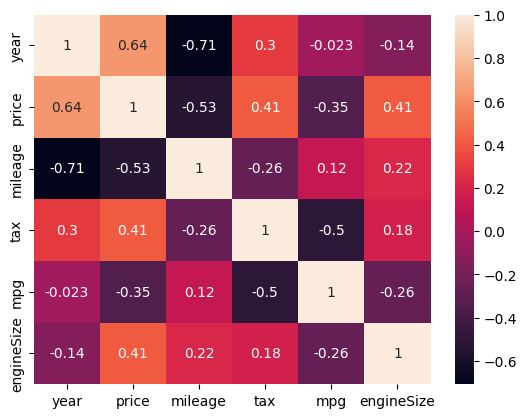

In [9]:
num = df.select_dtypes(include='number')

sns.heatmap(num.corr() , annot = True)

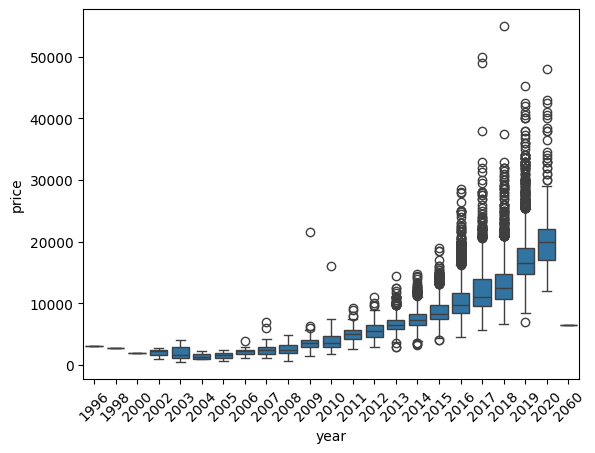

In [10]:
sns.boxplot(data = df , x = df['year'] , y  = df['price'] )
plt.xticks(rotation = 45)
plt.show()

<Axes: xlabel='transmission', ylabel='price'>

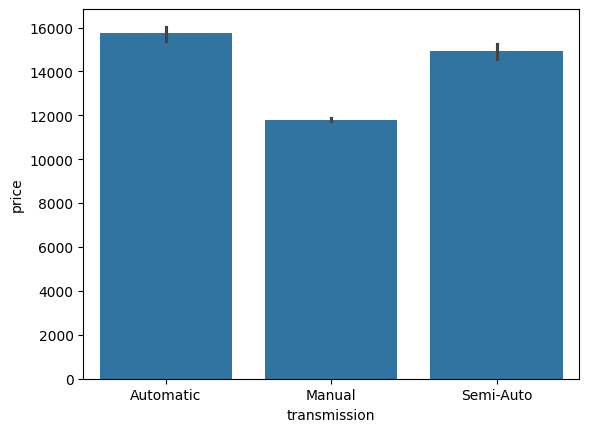

In [11]:
sns.barplot(y = df['price'] ,   x = df['transmission'] , data = df)

In [12]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

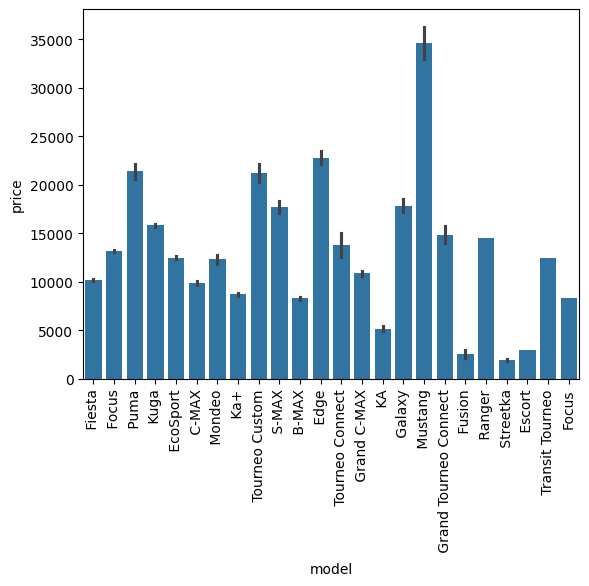

<Figure size 640x480 with 0 Axes>

In [13]:
sns.barplot(data = df , x = df['model'] , y = df['price'])
plt.xticks(rotation = 90)
plt.show()
plt.tight_layout()

<Axes: xlabel='fuelType', ylabel='price'>

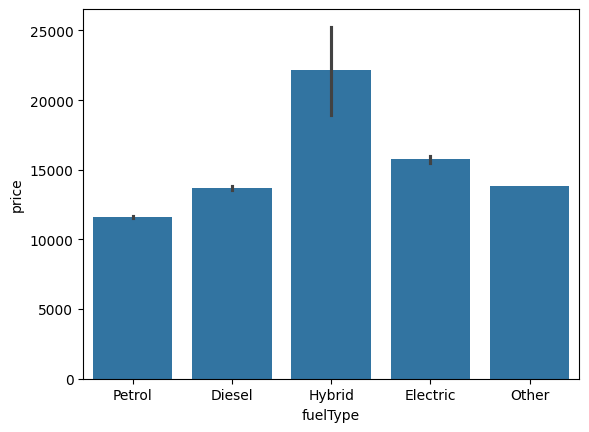

In [14]:
sns.barplot(data = df , x = df['fuelType'] , y = df['price'])

<Axes: xlabel='engineSize', ylabel='price'>

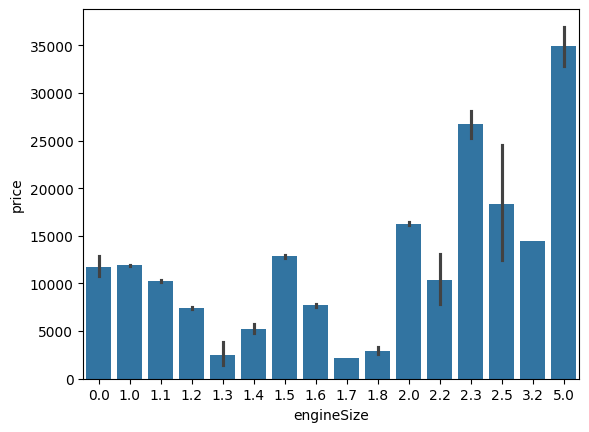

In [15]:
sns.barplot(data = df , x = df['engineSize'] , y = df['price'])

In [16]:
x = df[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize']]
y = df['price']

In [17]:
x 

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,Manual,5007,Petrol,145,57.7,1.2


In [18]:
x = pd.get_dummies(x , columns=['model' ,'transmission','fuelType'] , drop_first= True)

In [19]:
x 

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1,2018,9083,150,57.7,1.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,2017,12456,150,57.7,1.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,2019,10460,145,40.3,1.5,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
4,2019,1482,145,48.7,1.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47.1,1.4,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17962,2014,40700,30,57.7,1.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17963,2015,7010,20,67.3,1.6,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
17964,2018,5007,145,57.7,1.2,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


In [20]:
x = x.astype(int)

In [21]:
x

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,12456,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,10460,145,40,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,2019,1482,145,48,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,2014,40700,30,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,2015,7010,20,67,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,2018,5007,145,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [22]:
from sklearn.preprocessing import StandardScaler

num = ['year'	,'mileage'	,'tax'	,'mpg'	,'engineSize']

scaler = StandardScaler()

x[num] = scaler.fit_transform(x[num])

In [23]:
x 

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.380998,0.591358,-0.042122,-0.447984,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,0.552866,-0.733359,0.591358,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.065128,-0.560132,0.591358,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1.040605,-0.662640,0.510727,-1.721198,-0.447984,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,1.040605,-1.123724,0.510727,-0.931045,-0.447984,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.065128,-0.342172,0.591358,-1.029814,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,-1.398088,0.890398,-1.343791,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,-0.910349,-0.839822,-1.505053,0.945569,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,0.552866,-0.942690,0.510727,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [25]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

In [26]:
x_train

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
16054,-0.910349,1.789095,-1.343791,0.649262,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17266,-2.861303,2.589290,1.397670,-1.721198,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
15479,-0.422611,-0.324197,0.188202,-0.338430,-0.447984,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1575,0.552866,-0.190515,0.510727,-1.622429,1.820472,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
14613,-0.422611,0.457355,-1.827578,0.748031,-0.447984,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.552866,-0.706807,0.510727,-0.338430,-0.447984,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
11964,0.552866,-0.484020,0.510727,-1.622429,1.820472,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
5390,0.552866,-0.395892,0.510727,1.636954,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
860,0.065128,0.169498,0.510727,-0.338430,1.820472,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [27]:
from sklearn.ensemble import GradientBoostingRegressor

models = {
    "LinearRegression" : LinearRegression(),
    "RandomForestRegressor" : RandomForestRegressor(n_estimators=300, max_depth=None , min_samples_split=2 ),
    "DecisionTreeRegressor" : DecisionTreeRegressor(),
      "GradientBoosting": GradientBoostingRegressor()
}


In [28]:
result = []

for name , model in models.items():
    model.fit(x_train , y_train)

    y_pre = model.predict(x_test)

    r2 = r2_score(y_pre , y_test)
    mae = mean_absolute_error(y_pre , y_test)

    result.append({
        "model" : name,
        "R2_score" : r2
    })

In [29]:
result_df = pd.DataFrame(result).sort_values(by = 'R2_score' , ascending=False)
result_df

,model,R2_score
1,RandomForestRegressor,0.921518
3,GradientBoosting,0.893217
2,DecisionTreeRegressor,0.890639
0,LinearRegression,0.824031


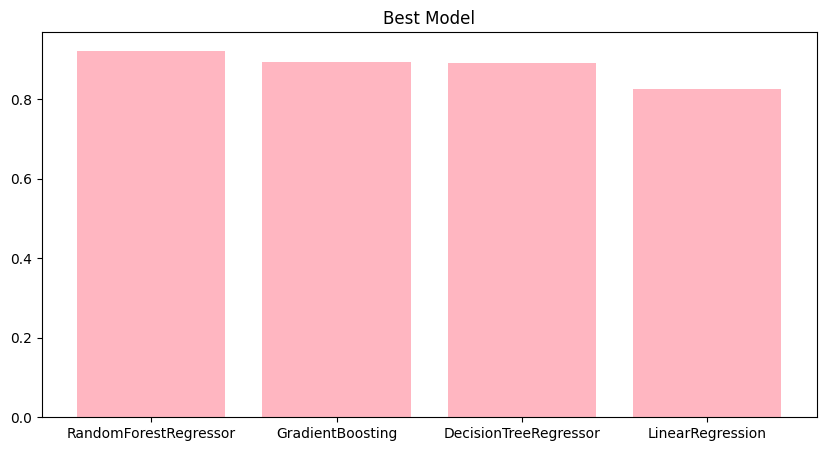

In [30]:
plt.figure(figsize=(10,5))
plt.bar(result_df['model'] , result_df['R2_score'] , color= 'lightpink')
plt.title('Best Model')
plt.show()